# Import all Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Import the Dataset

In [2]:
df=pd.read_csv('../input/titanic/train.csv')

# Data Overview

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 12)

In [7]:
df.drop(['PassengerId','Name','Ticket','Fare','Embarked'],axis=1, inplace=True)

In [8]:
df.loc[df['Sex']=='male','Sex']=1
df.loc[df['Sex']=='female','Sex']=0

# EDA

In [9]:
df['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

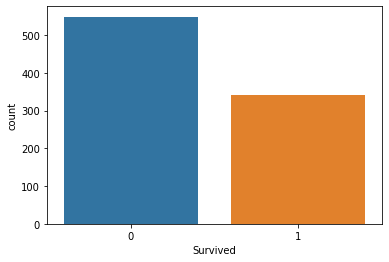

In [10]:
sns.countplot(data=df,x='Survived')

In [11]:
df.corr()['Survived'].sort_values()

Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Survived    1.000000
Name: Survived, dtype: float64

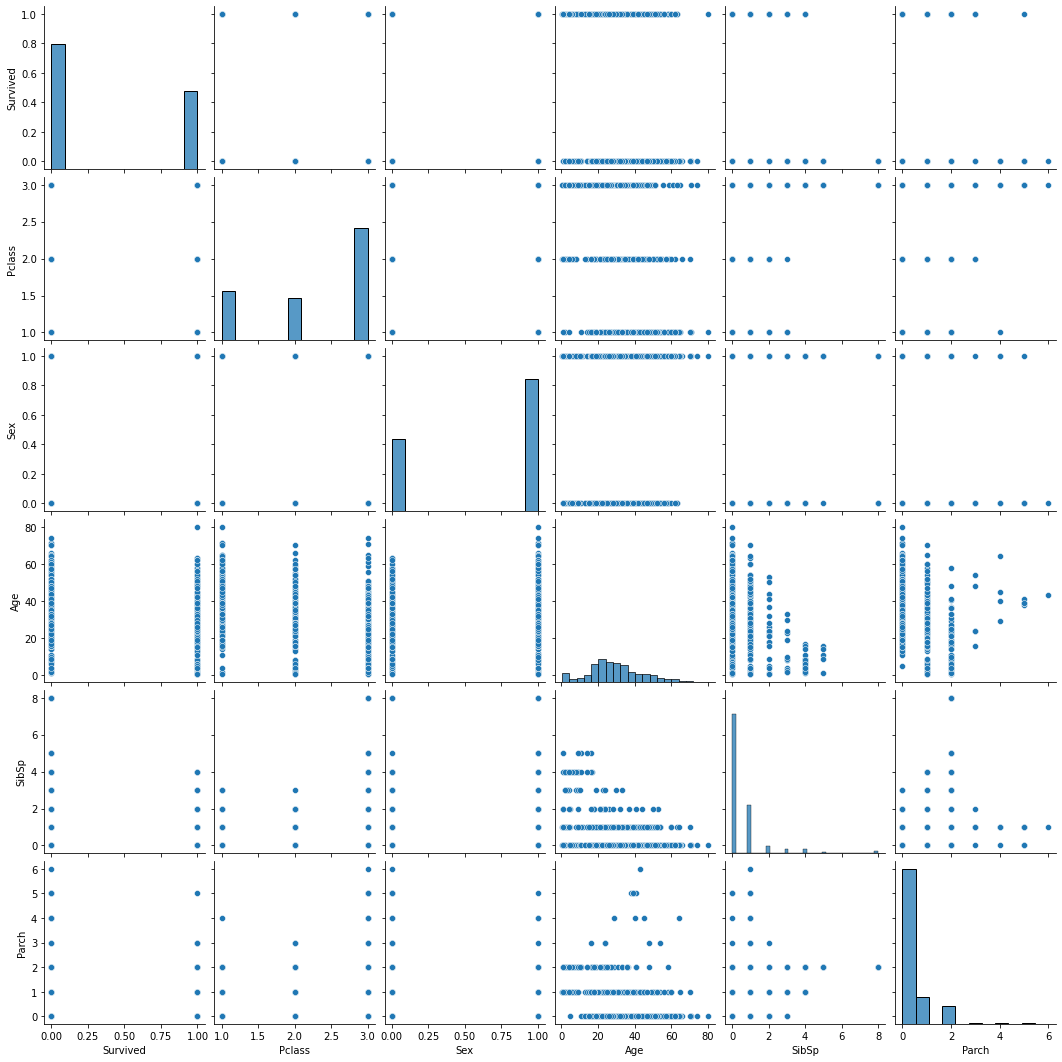

In [12]:
sns.pairplot(data=df)

<AxesSubplot:>

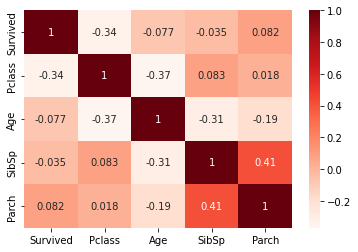

In [13]:
sns.heatmap(df.corr(), annot=True,cmap='Reds')

# Missing Data

In [14]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Cabin       687
dtype: int64

In [15]:
100*(df.isnull().sum()/len(df))

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Cabin       77.104377
dtype: float64

In [16]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [17]:
nan_percent= missing_percent(df)

In [18]:
nan_percent

Age      19.865320
Cabin    77.104377
dtype: float64

(array([0, 1]), [Text(0, 0, 'Age'), Text(1, 0, 'Cabin')])

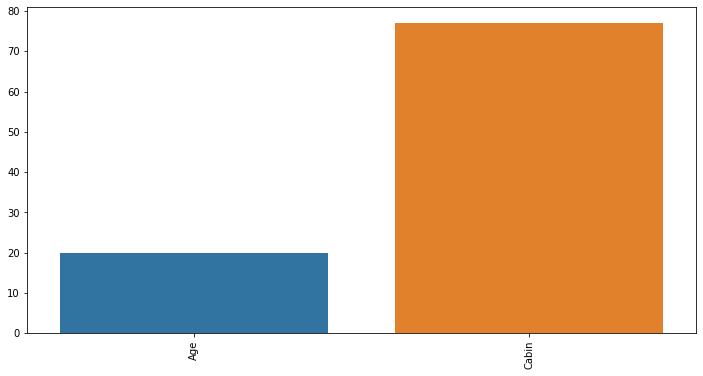

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [20]:
df.drop("Cabin", axis = 1, inplace = True)

In [21]:
df["Age"].fillna(df["Age"].mean(), inplace = True)

In [22]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
dtype: int64

# Features & Label

In [23]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [24]:
from sklearn.model_selection import train_test_split


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

# Scalling The Features

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler= StandardScaler()

In [28]:
scaler.fit(X_train)

StandardScaler()

In [29]:
scaled_X_train= scaler.transform(X_train)
scaled_X_test= scaler.transform(X_test)

# Train the Model

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
knn_model=KNeighborsClassifier(n_neighbors=1)

In [32]:
knn_model.fit(scaled_X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

# Predicting Test Data

In [33]:
y_pred=knn_model.predict(scaled_X_test)

In [34]:
#the prediction value vs actual value of test data
pd.DataFrame({'Y_Test':y_test,'Y_pred':y_pred})

,Y_Test,Y_pred
331,0,0
700,1,1
748,0,0
751,1,1
481,0,0
...,...,...
320,0,0
288,1,0
827,1,1
847,0,0


# Evaluating the Model

In [35]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [36]:
accuracy_score(y_test,y_pred)

0.7222222222222222

In [37]:
confusion_matrix(y_test,y_pred)

array([[43,  8],
       [17, 22]])

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.84      0.77        51
           1       0.73      0.56      0.64        39

    accuracy                           0.72        90
   macro avg       0.72      0.70      0.71        90
weighted avg       0.72      0.72      0.72        90



In [39]:
test_error_rate=[]


for k in range (1, 30):
    knn_model=KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train, y_train)
    
    y_pred_test= knn_model.predict(scaled_X_test)
    
    test_error=1-accuracy_score(y_test , y_pred_test)
    test_error_rate.append(test_error)

In [40]:
test_error_rate

[0.2777777777777778,
 0.2222222222222222,
 0.21111111111111114,
 0.1777777777777778,
 0.1777777777777778,
 0.2222222222222222,
 0.23333333333333328,
 0.24444444444444446,
 0.23333333333333328,
 0.23333333333333328,
 0.2222222222222222,
 0.24444444444444446,
 0.24444444444444446,
 0.2666666666666667,
 0.24444444444444446,
 0.25555555555555554,
 0.25555555555555554,
 0.2666666666666667,
 0.25555555555555554,
 0.2666666666666667,
 0.21111111111111114,
 0.25555555555555554,
 0.21111111111111114,
 0.2222222222222222,
 0.2222222222222222,
 0.2222222222222222,
 0.2222222222222222,
 0.2222222222222222,
 0.2222222222222222]

Text(0.5, 0, 'K Value')

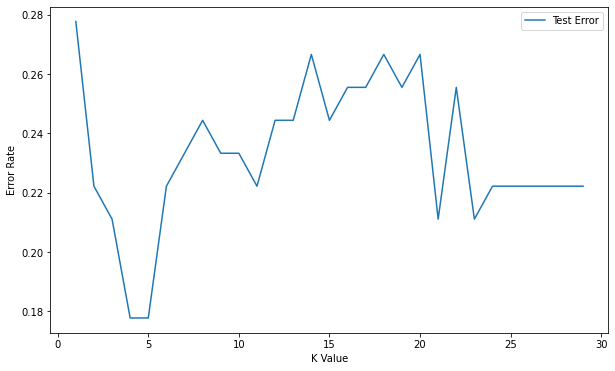

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), test_error_rate, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')

# Creating a Pipeline to find K value

In [42]:
scaler= StandardScaler()

In [43]:
knn= KNeighborsClassifier()

In [44]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [45]:
operations= [('scaler', scaler), ('knn', knn)]

In [46]:
from sklearn.pipeline import Pipeline

In [47]:
pipe= Pipeline(operations)

In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
k_values= list(range(1, 20))

In [50]:
param_grid= {'knn__n_neighbors': k_values}

In [51]:
full_cv_classifier= GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

In [52]:
full_cv_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [53]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=16))],
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=16),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 16,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [54]:
full_cv_classifier.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_knn__n_neighbors', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

# Final Model

In [55]:
scaler=StandardScaler()
knn14=KNeighborsClassifier(n_neighbors=14)
operations=[('scaler',scaler),('knn14',knn14)]

In [56]:
pipe= Pipeline(operations)

In [57]:
pipe.fit(X_train , y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn14', KNeighborsClassifier(n_neighbors=14))])

In [58]:
pipe_pred=pipe.predict(X_test)

In [59]:
print(classification_report(y_test,pipe_pred))

              precision    recall  f1-score   support

           0       0.71      0.90      0.79        51
           1       0.80      0.51      0.62        39

    accuracy                           0.73        90
   macro avg       0.75      0.71      0.71        90
weighted avg       0.75      0.73      0.72        90



In [60]:
sample= X_test.iloc[44]

In [61]:
sample

Pclass       2
Sex          1
Age       39.0
SibSp        0
Parch        0
Name: 808, dtype: object

In [62]:
sample.values

array([2, 1, 39.0, 0, 0], dtype=object)

In [63]:
sample.values.reshape(1, -1)

array([[2, 1, 39.0, 0, 0]], dtype=object)

In [64]:
pipe.predict(sample.values.reshape(1, -1))

array([0])

In [65]:
pipe.predict_proba(sample.values.reshape(1, -1))

array([[0.92857143, 0.07142857]])